In [1462]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Загрузка датасета

In [1463]:
data_path = "c:\\temp\\csv_files\\HomeWork.csv"
data = pd.read_csv(data_path)
data

,Unnamed: 0,status,income,age,timestamp
0,0,Student,4000.0,18.0,2026-03-02
1,1,Student,4000.0,18.0,2026-03-25
2,2,Student,0.0,0.0,2026-03-29
3,3,Student,1000.0,20.0,2026-03-05
4,4,Student,2000.0,22.0,2026-03-06
...,...,...,...,...,...
995,995,Working,63000.0,44.0,2026-03-02
996,996,Working,64000.0,41.0,2026-03-15
997,997,Pensioner,7000.0,61.0,2026-03-19
998,998,Working,65000.0,53.0,2026-03-08


Удалим первый столбец, это дублирование индекса

In [1464]:
data = data.drop("Unnamed: 0", axis=1)

## 1. Разведочный анализ

In [1465]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   status     994 non-null    object 
 1   income     823 non-null    float64
 2   age        968 non-null    float64
 3   timestamp  1000 non-null   object 
dtypes: float64(2), object(2)
memory usage: 31.4+ KB


In [1466]:
data.describe()

,income,age
count,823.000000,968.000000
mean,136234.967193,43.541322
std,171113.478156,19.098784
min,-13745.000000,0.000000
25%,5000.000000,29.000000
50%,96000.000000,43.000000
75%,205500.000000,57.000000
max,992000.000000,99.000000


In [1467]:
data["status"].value_counts()

status
Working        421
Businessman    274
Student        173
Pensioner      126
Name: count, dtype: int64

В датафрейме много пропусков:
- income: 177 пропусков
- age: 32 пропуска
- status: 6 пропусков

Есть странные значения
- мин. доход (-13745), явно некорректное значение
- мин. возраст (0)

Выбросы нужно проверить по различным группам
- макс. доход 992000 при среднем 136235 и медиане 96000
- макс. возраст 99

## Обработка выбросов

Построим Boxplot для данных, сгруппированных по status. Одно значение может быть выбросом для одного статуса, и нормальным для другого статуса

<Figure size 1000x500 with 0 Axes>

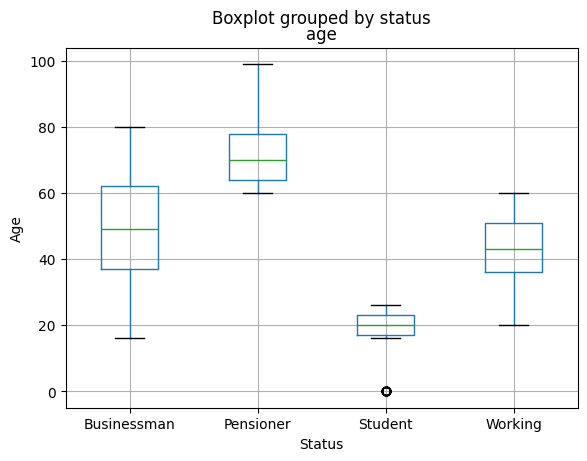

In [1468]:
plt.figure(figsize=(10, 5))
data.boxplot(column="age", by="status")
plt.ylabel("Age")
plt.xlabel("Status")
plt.grid(True)
plt.show()

Только одно значение может быть выбросом (для студента, age не может быть 0). Выброс единственный, удалим

In [1469]:
data = data.dropna(subset=["age"])

Построим теперь для доходов

<Figure size 1000x500 with 0 Axes>

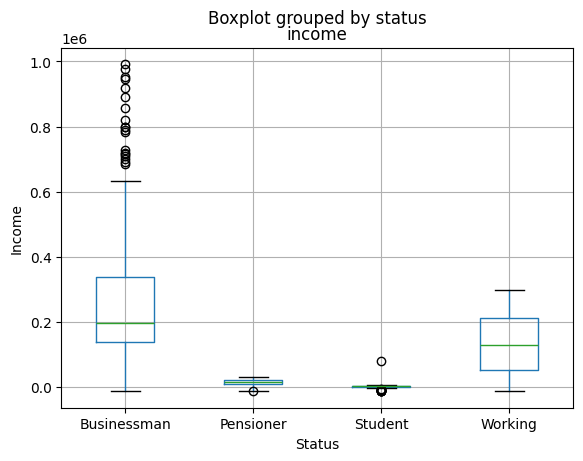

In [1470]:
plt.figure(figsize=(10, 5))
data.boxplot(column="income", by="status")
plt.ylabel("Income")
plt.xlabel("Status")
plt.grid(True)
plt.show()

Плохо видно графики и распределение для групп с малым разбросом дохода. Построим графики по отдельности (исключая NaN в статусах)

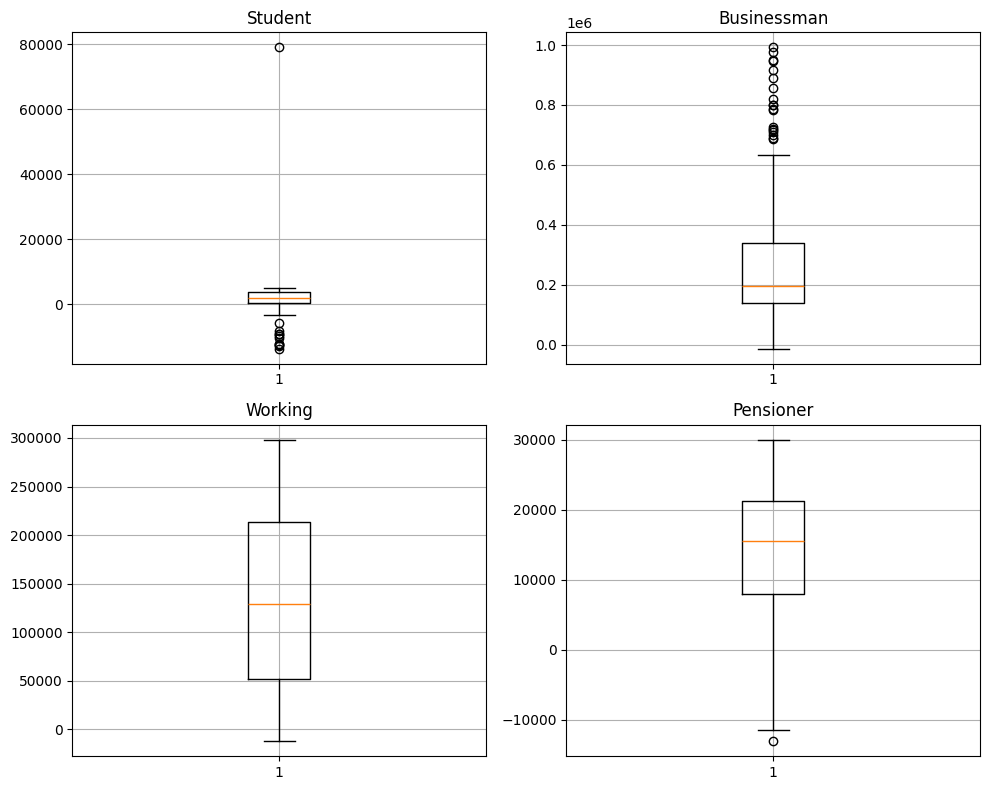

In [1471]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# убираем NaN из status и получаем все статусы
statuses = data["status"].dropna().unique()

for i, status in enumerate(statuses):
    status_data = data[data["status"] == status]["income"].dropna()
    axes[i].boxplot(status_data)
    axes[i].set_title(f"{status}")
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Распределение по доходам для бизнесменов

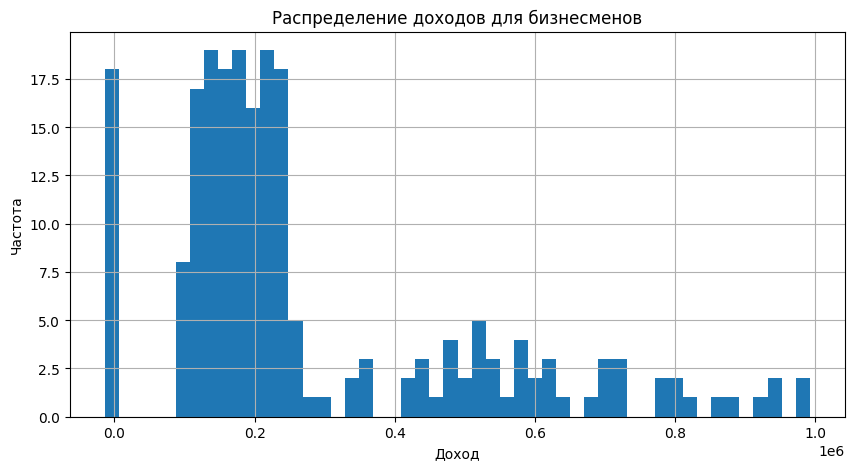

In [1472]:
plt.figure(figsize=(10, 5))
businessman_data = data[data["status"] == "Businessman"]["income"].dropna()
plt.hist(businessman_data, bins=50)
plt.title("Распределение доходов для бизнесменов")
plt.xlabel("Доход")
plt.ylabel("Частота")
plt.grid(True)
plt.show()

У working нормальное распределение по доходу, нет пропусков. У businessman распределение смещено влево, это не ошибка ввода. Реальные значения лучше оставить, но использовать алгоритмы, не чувствительные к выбросам (деревья). Если использовать линейные модели, то лучше прологарифмировать, но тогда снизится интепретируемость. У Pensioner есть довольно много отрицательных значений. У student тоже есть отрицательные доходы и один явный выброс с большим доходом.

Заменим большой доход у студента NaN.

In [1473]:
data.loc[(data["status"] == "Student") & (data["income"] > 60000)] = np.nan

Отрицательные доходы могут быть технической ошибкой при вводе данных, например. Нужно проверить

Преобразуем timestamp в тип данных datetime

In [1474]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

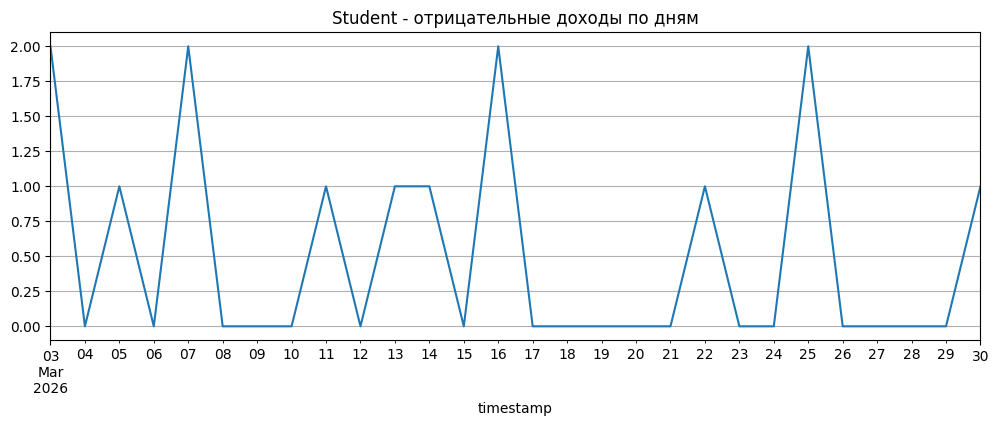

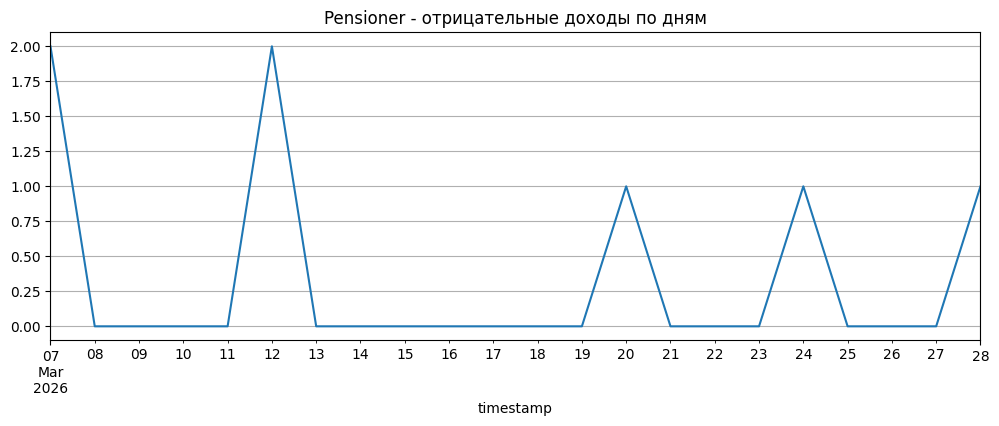

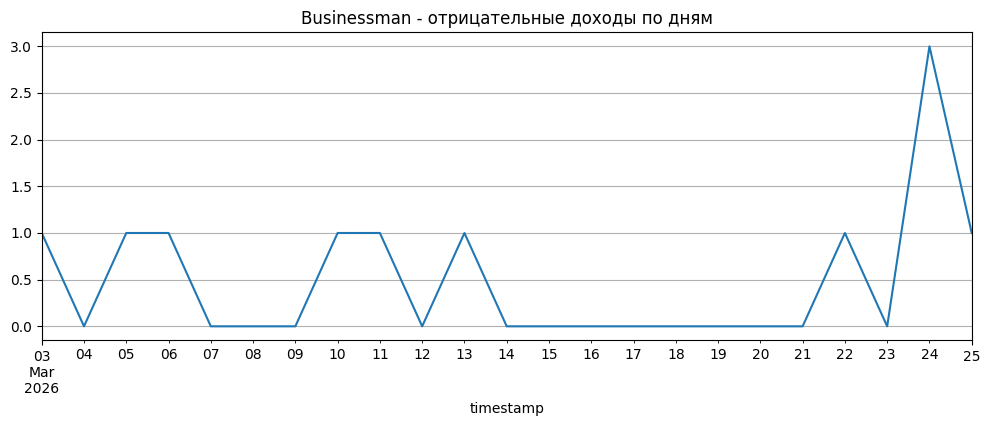

In [1475]:
for status in ["Student", "Pensioner", "Businessman"]:
    plt.figure(figsize=(12, 4))
    status_neg = data[(data["status"] == status) & (data["income"] < 0)]
    status_neg.resample("1d", on="timestamp")["income"].count().plot(
        title=f"{status} - отрицательные доходы по дням"
    )
    plt.grid(True)
    plt.show()

Отрицательный доход не зависит от времени. Выбросы носят случайный характер, нельзя утвеждать, что это систематическая ошибка. Можно заменить на NaN, как ошибка при вводе

In [1476]:
data.loc[data["income"] < 0, "income"] = np.nan

## Обработка пропусков

### Признак status

6 пропусков, выведем их

In [1477]:
data[data["status"].isna()]

,status,income,age,timestamp
362,NaN,NaN,NaN,NaT
411,NaN,66000.0,34.0,2026-03-19
521,NaN,NaN,34.0,2026-03-30
660,NaN,NaN,34.0,2026-03-24
678,NaN,NaN,29.0,2026-03-16
737,NaN,NaN,49.0,2026-03-14
740,NaN,NaN,54.0,2026-03-12


В случае с 411 объектом, это может быть неправильный ввод данных и status="Working". В остальных случаях, это могут быть безработные. Можно создать отдельную категорию Unemployed или удалить, так как объектов всего 5 и почти нет информативности

In [1478]:
data.loc[411, "status"] = "Working"

data = data.dropna(subset=["status"])

data["status"].value_counts()

status
Working        422
Businessman    255
Student        172
Pensioner      113
Name: count, dtype: int64

### Признак age

Заполним нули и пропуски возрастов

In [1479]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   status     962 non-null    object        
 1   income     752 non-null    float64       
 2   age        962 non-null    float64       
 3   timestamp  962 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 37.6+ KB


Пропусков нет. Проверим, есть ли нули

In [1480]:
data[data["age"] == 0]

,status,income,age,timestamp
2,Student,0.0,0.0,2026-03-29
15,Student,3000.0,0.0,2026-03-10
106,Student,NaN,0.0,2026-03-11
123,Student,2000.0,0.0,2026-03-28
143,Student,2000.0,0.0,2026-03-27
161,Student,NaN,0.0,2026-03-14
171,Student,5000.0,0.0,2026-03-05
175,Student,5000.0,0.0,2026-03-08
191,Student,4000.0,0.0,2026-03-25
195,Student,0.0,0.0,2026-03-22


Все строки с age==0 - это студенты. Можно заполнить медианой для студентов

In [1481]:
student_age_median = data[data["status"] == "Student"]["age"].median()

data.loc[data["age"] == 0, "age"] = student_age_median

In [1482]:
data[data["age"] == 0]

,status,income,age,timestamp


### Признак income

Проверим пропуски income

In [1483]:
data.groupby("status")["income"].apply(lambda x: x.isnull().sum())

status
Businessman    52
Pensioner      32
Student        41
Working        85
Name: income, dtype: int64

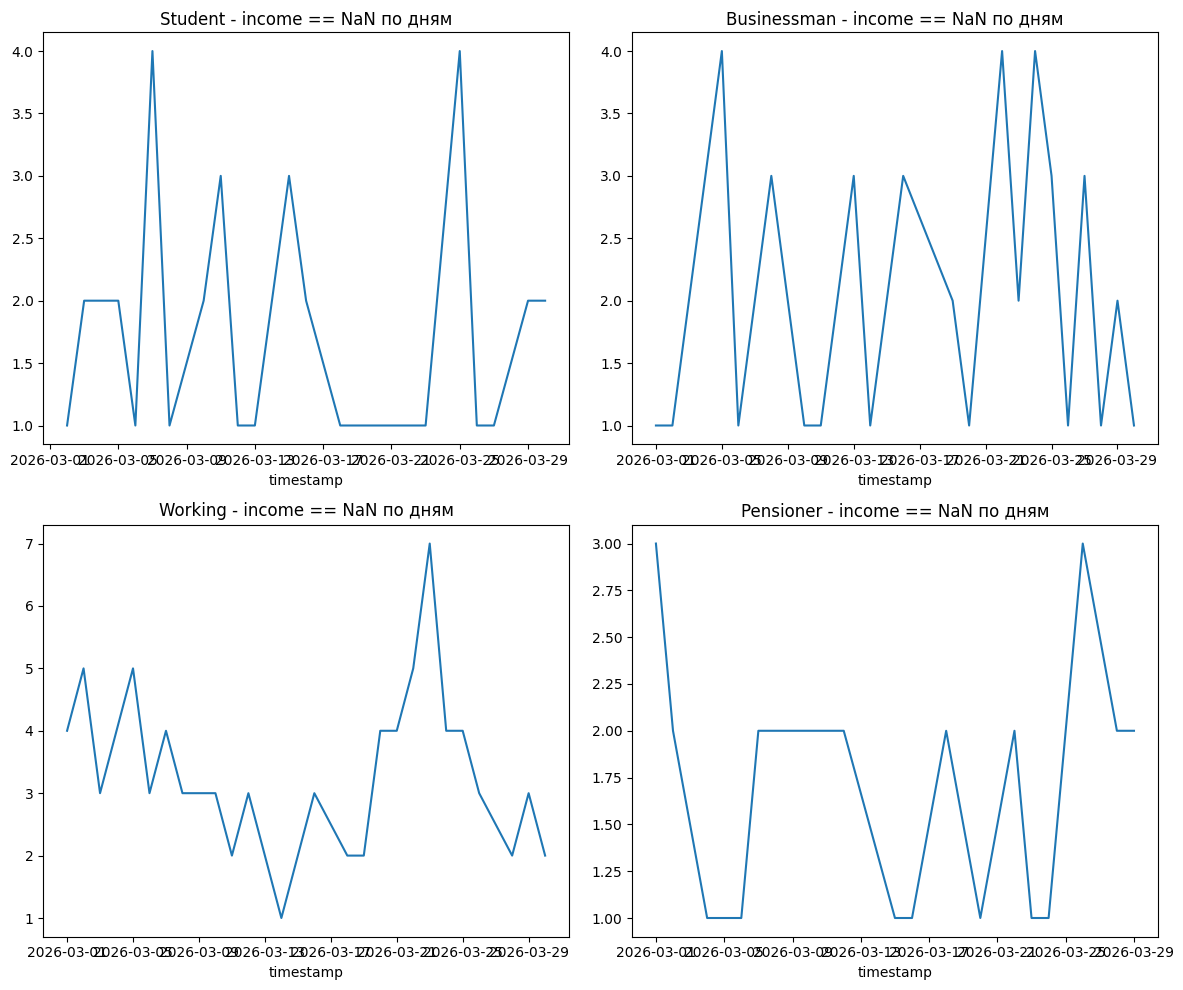

In [1484]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

statuses = data["status"].unique()

for i, status in enumerate(statuses):
    income_nan = data[(data["status"] == status) & (data["income"].isna())]
    income_nan.groupby(income_nan["timestamp"].dt.date).size().plot(
        ax=axes[i], title=f"{status} - income == NaN по дням"
    )

plt.tight_layout()
plt.show()

Никакой зависимости нет, можно заменить медианным значением для каждого статуса

Сформируем медианные значения дохода для каждого статуса

In [1485]:
income_by_status_median = data.groupby("status")["income"].median()
income_by_status_median

status
Businessman    205000.0
Pensioner       17000.0
Student          2000.0
Working        135000.0
Name: income, dtype: float64

In [1486]:
data["income"] = data["income"].fillna(data["status"].map(income_by_status_median))

Проверим нулевые значения дохода

In [1487]:
data.groupby("status")["income"].apply(lambda x: (x == 0).sum())

status
Businessman     7
Pensioner       4
Student        23
Working        12
Name: income, dtype: int64

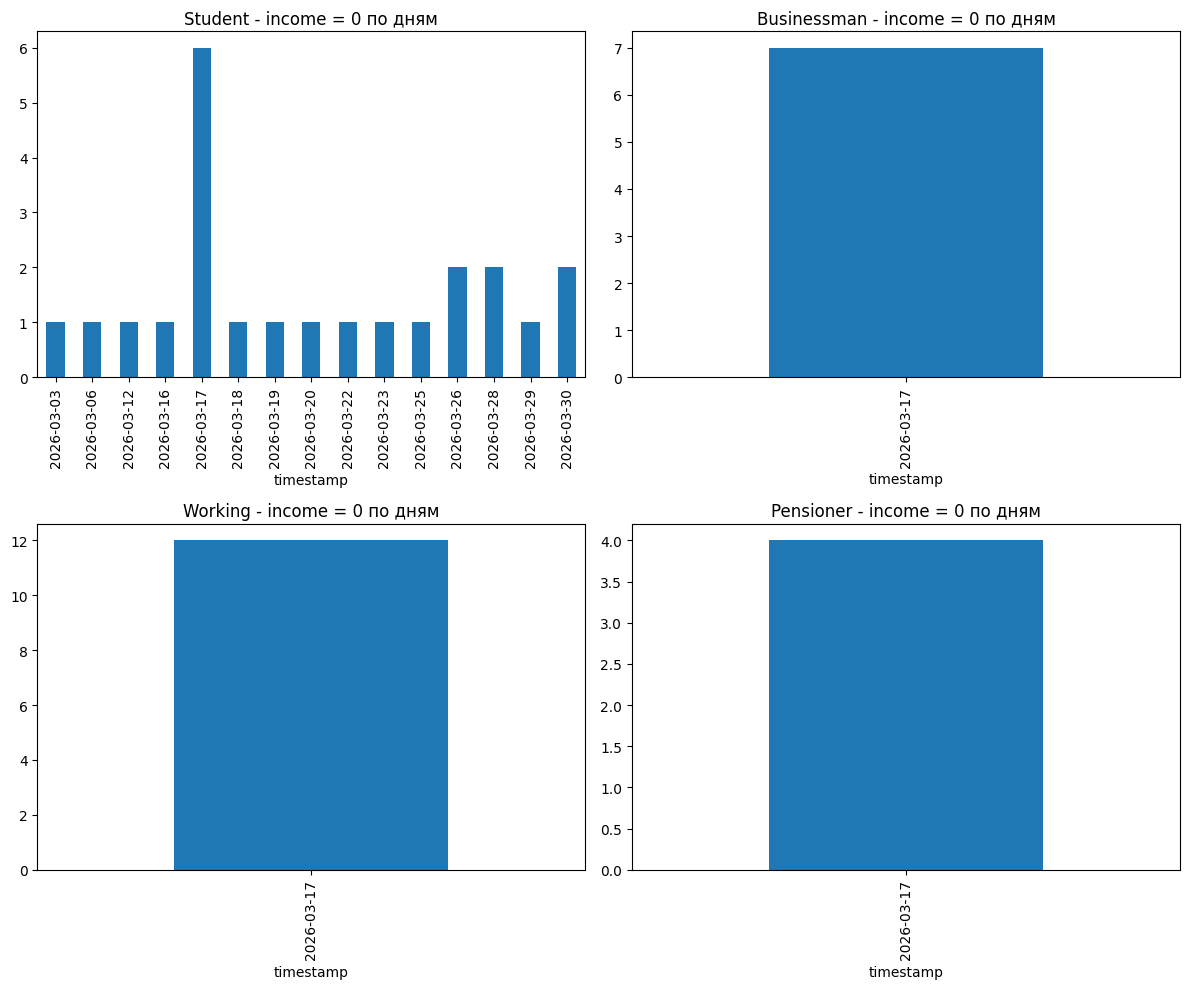

In [1488]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

statuses = data["status"].unique()

for i, status in enumerate(statuses):
    income_zero = data[(data["status"] == status) & (data["income"] == 0)]
    income_zero.groupby(income_zero["timestamp"].dt.date)["income"].count().plot(
        kind="bar", ax=axes[i], title=f"{status} - income = 0 по дням"
    )

plt.tight_layout()
plt.show()

Видно, что была какая-то ошибка при сборе income 17 марта. Только у студентов есть нулевые значения дохода в другие дни. Можно только эти нулевые значения заменить медианным по каждому статусу

In [1489]:
mask_17march = (data["timestamp"].dt.date == pd.to_datetime("2026-03-17").date()) & (
    data["income"] == 0
)

data.loc[mask_17march, "income"] = data["status"].map(income_by_status_median)

In [1490]:
data.groupby("status")["income"].apply(lambda x: (x == 0).sum())

status
Businessman     0
Pensioner       0
Student        17
Working         0
Name: income, dtype: int64

Остальные нулевые значения оставим. Они выглядят реальными для студентов.

In [1491]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 962 entries, 0 to 999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   status     962 non-null    object        
 1   income     962 non-null    float64       
 2   age        962 non-null    float64       
 3   timestamp  962 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 69.9+ KB


Все пропуски заменены

## Encoding

статус - категориальный признак. Так как признак - не порядковый, One-Hot Encoding подойдет для признака с 4 уникальными значениями. Оставим столбец status для сравнения с исходными данными

In [1492]:
data = data.reset_index(drop=True)

status_col = data["status"].copy()

data = pd.get_dummies(data, columns=["status"], prefix="status")

data["status"] = status_col

bool_cols = [col for col in data.columns if col.startswith("status_")]
data[bool_cols] = data[bool_cols].astype(int)

data

,income,age,timestamp,status_Businessman,status_Pensioner,status_Student,status_Working,status
0,4000.0,18.0,2026-03-02,0,0,1,0,Student
1,4000.0,18.0,2026-03-25,0,0,1,0,Student
2,0.0,20.0,2026-03-29,0,0,1,0,Student
3,1000.0,20.0,2026-03-05,0,0,1,0,Student
4,2000.0,22.0,2026-03-06,0,0,1,0,Student
...,...,...,...,...,...,...,...,...
957,63000.0,44.0,2026-03-02,0,0,0,1,Working
958,64000.0,41.0,2026-03-15,0,0,0,1,Working
959,7000.0,61.0,2026-03-19,0,1,0,0,Pensioner
960,65000.0,53.0,2026-03-08,0,0,0,1,Working


## Сравнение до/после

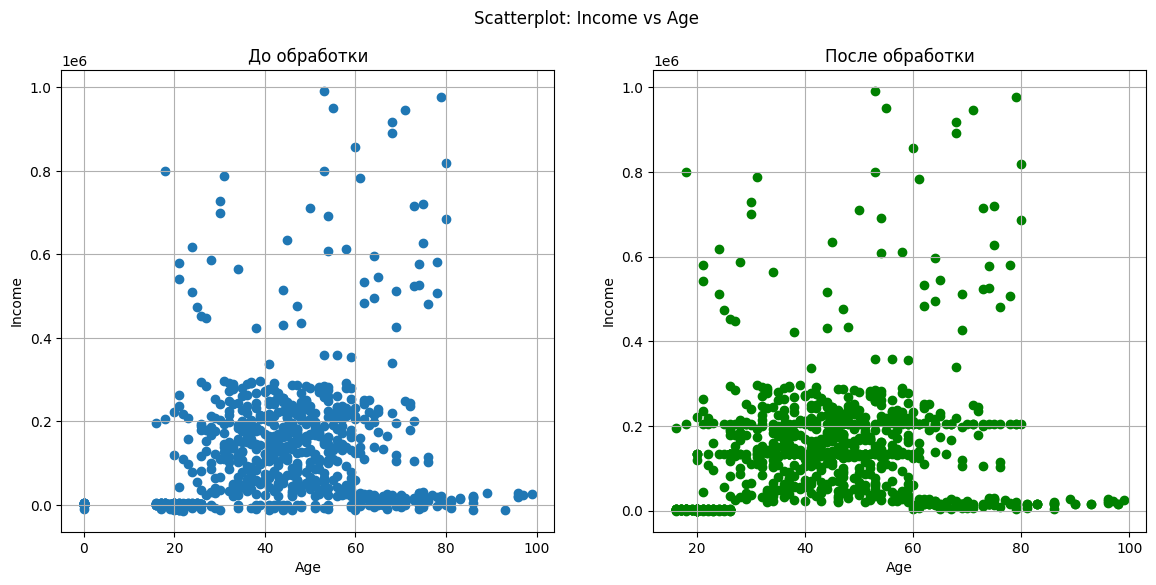

In [ ]:
data_before = pd.read_csv(data_path)
data_before = data_before.drop("Unnamed: 0", axis=1)

data_after = data.copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(data_before["age"], data_before["income"])
axes[0].set_title("До обработки")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Income")
axes[0].grid(True)

axes[1].scatter(data_after["age"], data_after["income"], color="green")
axes[1].set_title("После обработки")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Income")
axes[1].grid(True)

plt.suptitle("Scatterplot: Income vs Age")
plt.show()

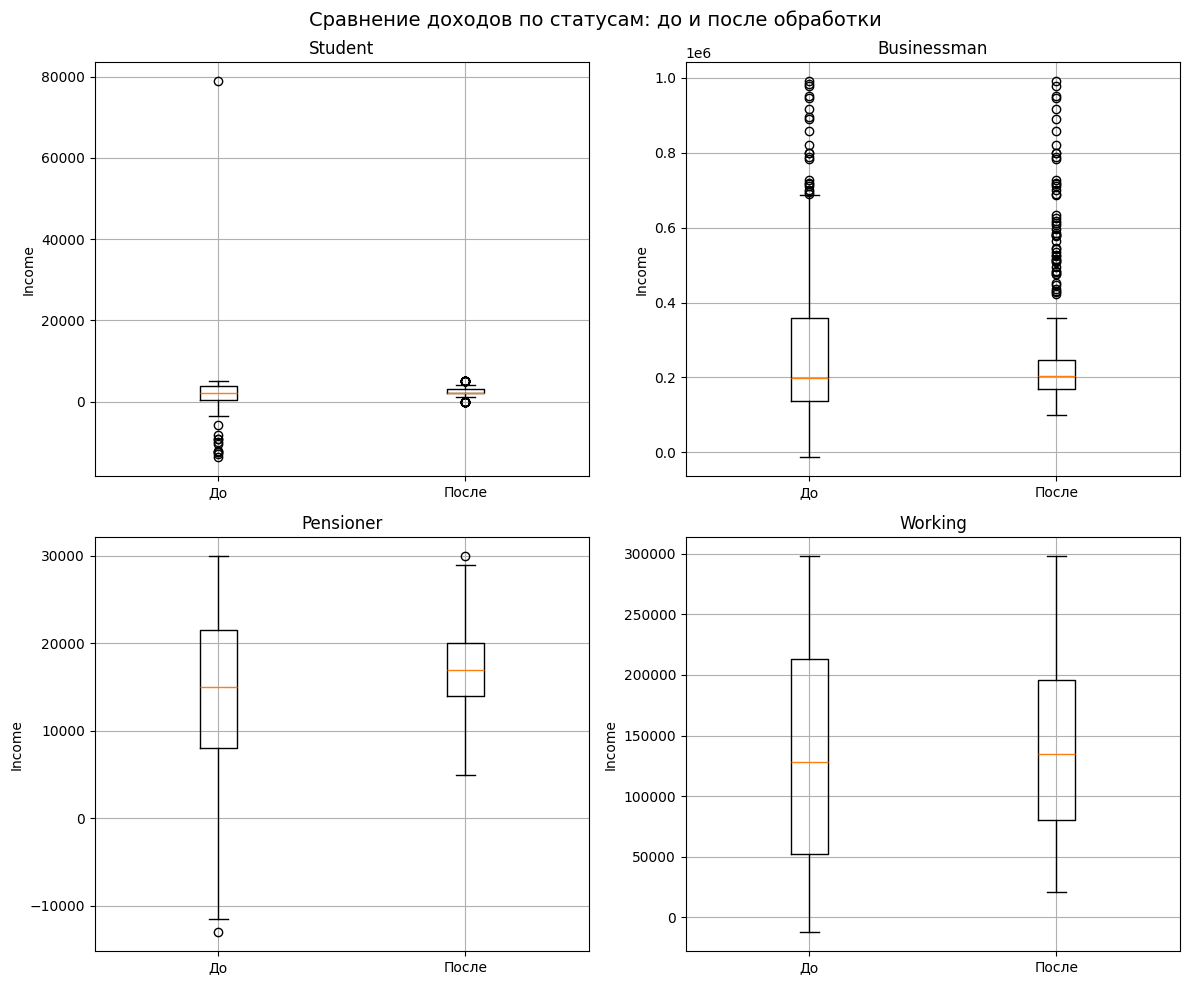

In [1494]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

statuses = data_before["status"].dropna().unique()

for i, status in enumerate(statuses):
    before_data = data_before[data_before["status"] == status]["income"].dropna()
    after_data = data_after[data_after["status"] == status]["income"].dropna()

    axes[i].boxplot([before_data, after_data], tick_labels=["До", "После"])
    axes[i].set_title(f"{status}")
    axes[i].set_ylabel("Income")
    axes[i].grid(True)

plt.suptitle("Сравнение доходов по статусам: до и после обработки", fontsize=14)
plt.tight_layout()
plt.show()

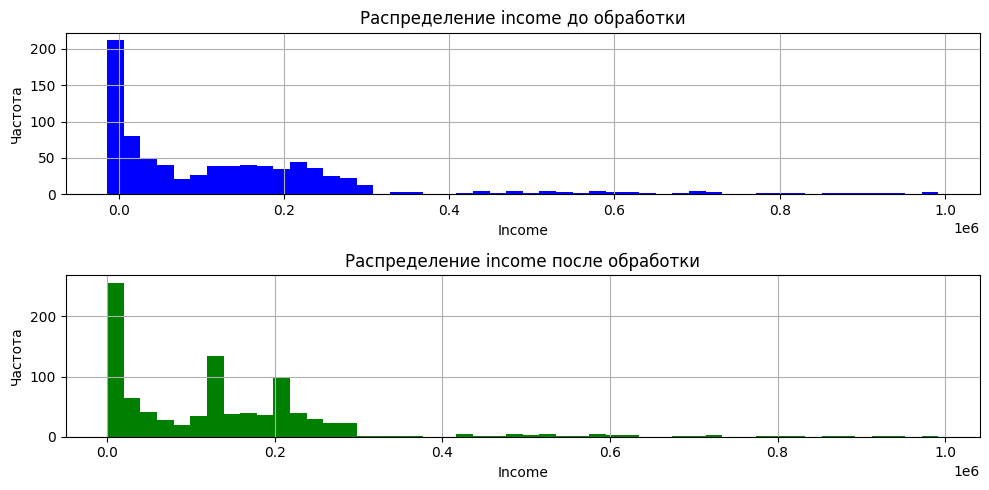

In [1495]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].hist(data_before["income"].dropna(), bins=50, color="blue")
axes[0].set_title("Распределение income до обработки")
axes[0].set_xlabel("Income")
axes[0].set_ylabel("Частота")
axes[0].grid(True)

axes[1].hist(data_after["income"], bins=50, color="green")
axes[1].set_title("Распределение income после обработки")
axes[1].set_xlabel("Income")
axes[1].set_ylabel("Частота")
axes[1].grid(True)

plt.tight_layout()
plt.show()

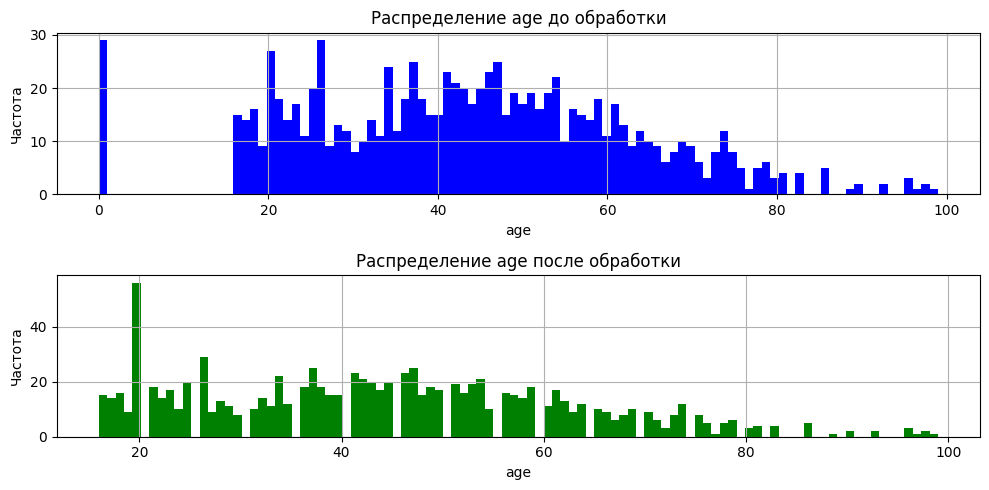

In [1496]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5))

axes[0].hist(data_before["age"].dropna(), bins=100, color="blue")
axes[0].set_title("Распределение age до обработки")
axes[0].set_xlabel("age")
axes[0].set_ylabel("Частота")
axes[0].grid(True)

axes[1].hist(data_after["age"], bins=100, color="green")
axes[1].set_title("Распределение age после обработки")
axes[1].set_xlabel("age")
axes[1].set_ylabel("Частота")
axes[1].grid(True)

plt.tight_layout()
plt.show()

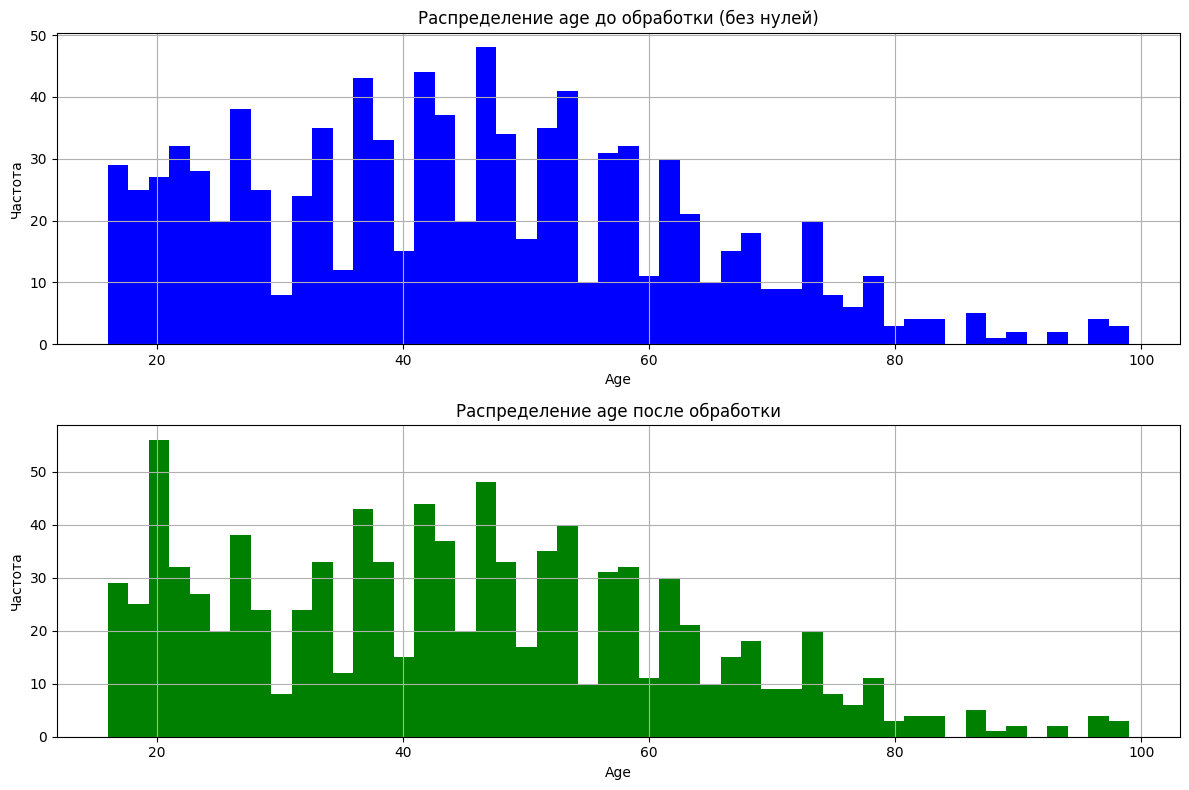

In [1497]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

age_before_clean = data_before["age"].dropna()
age_before_clean = age_before_clean[age_before_clean != 0]

axes[0].hist(age_before_clean, bins=50, color="blue")
axes[0].set_title("Распределение age до обработки (без нулей)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Частота")
axes[0].grid(True)

axes[1].hist(data_after["age"], bins=50, color="green")
axes[1].set_title("Распределение age после обработки")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Частота")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Вывод

Данные стали чище, но почти сохранили структуру. Основная масса точек осталась на месте, убраны только явные ошибки (age=0, income<0) и пропуски.

Scatterplot:

- до обработки были хаотичные точки внизу (age=0, income=0 и отрицательные)
- после обработки появились горизонтальные полосы (из-за замены на медианы)

Boxplot:

- медианы практически не изменились, "усы" стали короче

HistPlot (Income):

- после обработки появились выраженные пики из-за заполнения медианой

HistPlot (Age):

- за счет того, что заменяли нулевые значения возраста у студентов медианой, появилось пиковое значение

У businessman распределение дохода смещено влево, это не ошибка ввода. Реальные значения лучше оставить, но использовать алгоритмы, не чувствительные к выбросам (деревья). Если использовать линейные модели, то лучше прологарифмировать, но тогда снизится интепретируемость

Данные стали чище, но ценой появления артефактов (пики, полосы) из-за массовой замены пропусков медианными значениями.

Был применен One-Hot Encoding, так как категориальный признак имеет 4 уникальных значения и не является порядковым